In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import ast

import matplotlib.pyplot as plt
import numpy as np

from tabpfn_sbi.utils.plot_utils import DEFAULT_COLORS, query, use_style

In [3]:
name = "../../main_results/flexible_noise"

In [20]:
def plot_noise_comparison(feature_dist, noise_dist, show=False, save=True):
    df = query(name)

    # add keys
    cfg_dicts = df["cfg"].apply(ast.literal_eval)

    # Extract nested parameters from cfg.task.params
    df["feature_dist"] = cfg_dicts.apply(lambda x: x["task"]["params"]["feature_dist"])
    df["noise_dist"] = cfg_dicts.apply(lambda x: x["task"]["params"]["noise_dist"])
    df["feature_scale"] = cfg_dicts.apply(
        lambda x: x["task"]["params"]["feature_scale"]
    )
    df["noise_scale"] = cfg_dicts.apply(lambda x: x["task"]["params"]["noise_scale"])
    df["dim"] = cfg_dicts.apply(lambda x: x["task"]["params"]["dim"])

    # filter for the specified distributions
    df = df[(df["feature_dist"] == feature_dist) & (df["noise_dist"] == noise_dist)]

    # get unique values for plotting
    feature_scales = sorted(df["feature_scale"].unique())
    dims = sorted(df["dim"].unique())
    noise_scales = sorted(df["noise_scale"].unique())

    # Create the plot
    with use_style("pyloric"):
        # Create a figure with rows for feature_scale and columns for dim
        fig, axes = plt.subplots(
            len(feature_scales),
            len(dims),
            figsize=(1.7 * len(dims), 1.1 * len(feature_scales)),
            squeeze=False,
            sharex=True,
            sharey=True,
        )

        # Create handles for the legend
        legend_handles = []
        legend_labels = []

        # Add method handles (solid for NPE, dashed for TabPFN)
        (npe_handle,) = plt.plot(
            [],
            [],
            color=plt.rcParams["axes.prop_cycle"].by_key()["color"][0],
            linestyle="-",
            marker="o",
        )
        (tabpfn_handle,) = plt.plot(
            [],
            [],
            color=plt.rcParams["axes.prop_cycle"].by_key()["color"][1],
            linestyle="-",
            marker="s",
        )
        legend_handles.extend([npe_handle, tabpfn_handle])
        legend_labels.extend(["NPE-Flow", "NPE-PF"])

        # Add separator
        # legend_handles.append(plt.Line2D([0], [0], color="none"))
        # legend_labels.append("scale (noise)")

        # Add noise scale handles with different line styles
        line_styles = ["-", "--", ":"]  # solid, dashed, dotted
        for ns_idx, noise_scale in enumerate(noise_scales):
            (ns_handle,) = plt.plot(
                [], [], color="gray", linestyle=line_styles[ns_idx % len(line_styles)]
            )
            legend_handles.append(ns_handle)
            legend_labels.append(f"{noise_scale} scale (noise)")

        # Iterate through rows (feature_scales)
        for i, feature_scale in enumerate(feature_scales):
            # Iterate through columns (dims)
            for j, dim in enumerate(dims):
                ax = axes[i, j]

                # Set title for first row
                if i == 0:
                    ax.set_title(f"{dim} dims.")

                # Set y-label for first column
                if j == 0:
                    ax.set_ylabel(f"scale(x)={feature_scale}\nC2ST")

                # Set x-label for last row
                if i == len(feature_scales) - 1:
                    ax.set_xlabel("Num. sim.")

                # Iterate through noise scales for this feature_scale and dim
                for ns_idx, noise_scale in enumerate(noise_scales):
                    # Get line style based on noise scale
                    line_style = line_styles[ns_idx % len(line_styles)]

                    # NPE line with error bars
                    npe_data = df[
                        (df["method"] == "npe")
                        & (df["feature_scale"] == feature_scale)
                        & (df["dim"] == dim)
                        & (df["noise_scale"] == noise_scale)
                    ]

                    if not npe_data.empty:
                        # Group by num_simulations and calculate mean and std
                        npe_stats = (
                            npe_data.groupby("num_simulations")["value"]
                            .agg(["mean", "std"])
                            .reset_index()
                        )

                        # Plot with error bars
                        ax.errorbar(
                            npe_stats["num_simulations"],
                            npe_stats["mean"],
                            yerr=npe_stats["std"],
                            color=DEFAULT_COLORS["npe"],
                            marker="o",
                            capsize=4,
                            linestyle=line_style,
                        )

                    # TabPFN line with error bars
                    tabpfn_data = df[
                        (df["method"] == "tabpfn")
                        & (df["feature_scale"] == feature_scale)
                        & (df["dim"] == dim)
                        & (df["noise_scale"] == noise_scale)
                    ]

                    if not tabpfn_data.empty:
                        # Group by num_simulations and calculate mean and std
                        tabpfn_stats = (
                            tabpfn_data.groupby("num_simulations")["value"]
                            .agg(["mean", "std"])
                            .reset_index()
                        )

                        # Plot with error bars
                        ax.errorbar(
                            tabpfn_stats["num_simulations"],
                            tabpfn_stats["mean"],
                            yerr=tabpfn_stats["std"],
                            color=DEFAULT_COLORS["filtered_tabpfn"],
                            marker="s",
                            capsize=4,
                            linestyle=line_style,
                        )

                # Add grid
                ax.grid(True, alpha=0.3)

                # Set y-axis limits to be consistent (optional)
                ax.set_ylim(0.5, 1.0)
                # change xtick size
                # ax.tick_params(axis='x', labelsize=7)
                # set x-ticks to be 10^2, 10^3, 2*10^3
                ax.set_xticks([100, 1000, 2000])
                ax.set_xticklabels([r"$10^2$", r"$10^3$", r"$2 \cdot 10^3$"])

        # # Add a common legend
        # fig.legend(
        #     legend_handles,
        #     legend_labels,
        #     loc="lower center",
        #     ncol=1,  # Three columns: NPE, TabPFN, and scales
        #     bbox_to_anchor=(0.5, -0.05),
        #     columnspacing=1.0  # Increase space between columns
        # )

        # Adjust layout
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.3)  # Make room for the legend

        # Add a super title
        plt.suptitle(
            f"{feature_dist.capitalize()} Features, {noise_dist.capitalize()} Noise",
            # fontsize=16,
            y=1.0,
        )

        # Create filename based on distributions
        filename = f"{feature_dist}_{noise_dist}_comparison"
        if save:
            fig.savefig(f"{filename}.svg", bbox_inches="tight", transparent=True)
        if show:
            plt.show()
        plt.close()

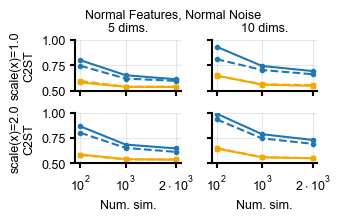

In [21]:
feature_dist = "normal"
noise_dist = "normal"
plot_noise_comparison(feature_dist, noise_dist, show=True, save=False)

In [22]:
for feature_dist, noise_dist in [
    ("laplace", "cauchy"),
    ("laplace", "normal"),
    ("logitnormal", "studentt"),
    ("studentt", "laplace"),
]:
    print(f"Plotting {feature_dist} and {noise_dist}...")
    try:
        plot_noise_comparison(feature_dist, noise_dist)
    except Exception as e:
        print(f"Error plotting {feature_dist} and {noise_dist}: {e}")

Plotting laplace and cauchy...
Plotting laplace and normal...
Plotting logitnormal and studentt...
Plotting studentt and laplace...


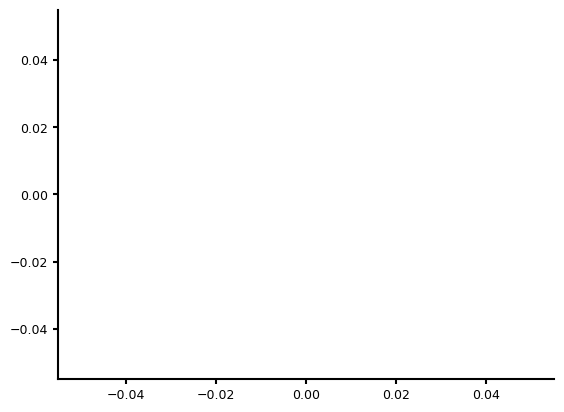

In [19]:
def save_legend():
    # Create handles for the legend
    with use_style("pyloric"):
        legend_handles = []
        legend_labels = []

        # Add method handles
        (npe_handle,) = plt.plot(
            [], [], color=DEFAULT_COLORS["npe"], linestyle="-", marker="o"
        )
        (tabpfn_handle,) = plt.plot(
            [], [], color=DEFAULT_COLORS["filtered_tabpfn"], linestyle="-", marker="s"
        )
        legend_handles.extend([npe_handle, tabpfn_handle])
        legend_labels.extend(["NPE", "NPE-PF"])

        # Add noise scale handles
        line_styles = ["-", "--"]
        noise_scales = ["1.0", "2.0"]  # Example values
        for ns_idx, noise_scale in enumerate(noise_scales):
            (ns_handle,) = plt.plot(
                [], [], color="gray", linestyle=line_styles[ns_idx % len(line_styles)]
            )
            legend_handles.append(ns_handle)
            legend_labels.append(f"scale (noise)={noise_scale}")

        # Create and save the legend
        fig_legend = plt.figure(figsize=(1.5, 0.7))
        ax = fig_legend.add_subplot(111)
        ax.legend(legend_handles, legend_labels, loc="center", ncol=1)
        ax.axis("off")
        fig_legend.savefig("legend_only.svg", bbox_inches="tight", transparent=True)
        # plt.show()
        plt.close()


save_legend()

In [ ]:
# only run this if you want all plot combinations!!!

## for feature_dist in [
##     "normal",
##     "studentt",
##     "laplace",
##     "cauchy",
##     "logistic",
##     "logitnormal",
## ]:
##     for noise_dist in [
##         "normal",
##         "studentt",
##         "laplace",
##         "cauchy",
##         "logistic",
##         "logitnormal",
##     ]:
##         print(f"Plotting {feature_dist} and {noise_dist}...")
##         try:
##             plot_noise_comparison(feature_dist, noise_dist)
##         except Exception as e:
##             print(f"Error plotting {feature_dist} and {noise_dist}: {e}")

Plotting normal and normal...
Plotting normal and studentt...
Plotting normal and laplace...
Plotting normal and cauchy...
Plotting normal and logistic...
Plotting normal and logitnormal...
Plotting studentt and normal...
Plotting studentt and studentt...
Plotting studentt and laplace...
Plotting studentt and cauchy...
Plotting studentt and logistic...
Plotting studentt and logitnormal...
Plotting laplace and normal...
Plotting laplace and studentt...
Plotting laplace and laplace...
Plotting laplace and cauchy...
Plotting laplace and logistic...
Plotting laplace and logitnormal...
Plotting cauchy and normal...
Plotting cauchy and studentt...
Plotting cauchy and laplace...
Plotting cauchy and cauchy...
Plotting cauchy and logistic...
Plotting cauchy and logitnormal...
Plotting logistic and normal...
Plotting logistic and studentt...
Plotting logistic and laplace...
Plotting logistic and cauchy...
Plotting logistic and logistic...
Plotting logistic and logitnormal...
Plotting logitnormal

In [16]:
def plot_heatmap(noise_scale, feature_scale, num_simulations, dim, show=False):
    df = query(name)

    # add keys
    cfg_dicts = df["cfg"].apply(ast.literal_eval)

    # Extract nested parameters from cfg.task.params
    df["feature_dist"] = cfg_dicts.apply(lambda x: x["task"]["params"]["feature_dist"])
    df["noise_dist"] = cfg_dicts.apply(lambda x: x["task"]["params"]["noise_dist"])
    df["feature_scale"] = cfg_dicts.apply(
        lambda x: x["task"]["params"]["feature_scale"]
    )
    df["noise_scale"] = cfg_dicts.apply(lambda x: x["task"]["params"]["noise_scale"])
    df["dim"] = cfg_dicts.apply(lambda x: x["task"]["params"]["dim"])

    # # filter for the specified distributions
    # df = df[(df["feature_dist"] == feature_dist) & (df["noise_dist"] == noise_dist)]
    # filter for the specified noise and feature scales
    df = df[(df["noise_scale"] == noise_scale) & (df["feature_scale"] == feature_scale)]
    # filter for the specified number of simulations
    df = df[df["num_simulations"] == num_simulations]
    # filter for the specified dimension
    df = df[df["dim"] == dim]

    # remove 'logistic' from noise_dist and feature_dist
    df = df[df["noise_dist"] != "logistic"]
    df = df[df["feature_dist"] != "logistic"]

    # filter for the specified method
    df_tabpfn = df[df["method"] == "tabpfn"]
    df_npe = df[df["method"] == "npe"]

    # get unique values for plotting
    feature_scales = sorted(df["feature_scale"].unique())
    dims = sorted(df["dim"].unique())
    noise_scales = sorted(df["noise_scale"].unique())

    # Get all unique feature and noise distributions in the data
    feature_distributions = sorted(df["feature_dist"].unique())
    noise_distributions = sorted(df["noise_dist"].unique())

    # Create empty matrices to store values for the heatmaps
    heatmap_npe = np.full(
        (len(feature_distributions), len(noise_distributions)), np.nan
    )
    heatmap_tabpfn = np.full(
        (len(feature_distributions), len(noise_distributions)), np.nan
    )

    # Fill matrices with values
    for i, feat_dist in enumerate(feature_distributions):
        for j, noise_dist in enumerate(noise_distributions):
            # Filter data for this combination
            npe_filtered = df_npe[
                (df_npe["feature_dist"] == feat_dist)
                & (df_npe["noise_dist"] == noise_dist)
            ]
            tabpfn_filtered = df_tabpfn[
                (df_tabpfn["feature_dist"] == feat_dist)
                & (df_tabpfn["noise_dist"] == noise_dist)
            ]

            # Get the value (assuming there's a 'value' column)
            if not npe_filtered.empty:
                heatmap_npe[i, j] = npe_filtered["value"].mean()

            if not tabpfn_filtered.empty:
                heatmap_tabpfn[i, j] = tabpfn_filtered["value"].mean()

    # Create custom colormap with white for NaN values
    cmap = plt.cm.viridis.copy()
    cmap.set_bad("white", 1.0)

    with use_style("pyloric"):
        # Create the heatmaps with more space for colorbar
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(2, 1))
        tickfontsize = 7

        # NPE heatmap
        im1 = ax1.imshow(heatmap_npe, cmap=cmap, vmin=0.5, vmax=1.0)
        ax1.set_title("NPE")  # , fontsize=14)
        ax1.set_xticks(np.arange(len(noise_distributions)))
        ax1.set_yticks(np.arange(len(feature_distributions)))
        ax1.set_xticklabels(
            noise_distributions, rotation=45, ha="right", fontsize=tickfontsize
        )
        ax1.set_yticklabels(
            feature_distributions, rotation=45, ha="right", fontsize=tickfontsize
        )
        ax1.set_xlabel("Noise Dist.")  # , fontsize=12)
        ax1.set_ylabel("Feature Dist.")  # , fontsize=12)

        # # Add values to each cell in NPE heatmap
        # for i in range(len(feature_distributions)):
        #     for j in range(len(noise_distributions)):
        #         if np.isnan(heatmap_npe[i, j]):
        #             text = ax1.text(j, i, "N/A", ha="center", va="center")
        #         else:
        #             text = ax1.text(j, i, f'{heatmap_npe[i, j]:.3f}',
        #                         ha="center", va="center",
        #                         color="w" if heatmap_npe[i, j] < 0.75 else "black")

        # TabPFN heatmap
        im2 = ax2.imshow(heatmap_tabpfn, cmap=cmap, vmin=0.5, vmax=1.0)
        ax2.set_title("NPE-PF")  # , fontsize=14)
        ax2.set_xticks(np.arange(len(noise_distributions)))
        ax2.set_yticks(np.arange(len(feature_distributions)))
        ax2.set_xticklabels(
            noise_distributions, rotation=45, ha="right", fontsize=tickfontsize
        )
        # ax2.set_yticklabels(feature_distributions, rotation=45, ha='right', fontsize=tickfontsize)
        ax2.set_yticklabels(
            ["", "", "", "", ""], rotation=45, ha="right", fontsize=tickfontsize
        )
        ax2.set_xlabel("Noise Dist.")  # , fontsize=12)
        # ax2.set_ylabel('Feature Distribution')#, fontsize=12)

        # # Add values to each cell in TabPFN heatmap
        # for i in range(len(feature_distributions)):
        #     for j in range(len(noise_distributions)):
        #         if np.isnan(heatmap_tabpfn[i, j]):
        #             text = ax2.text(j, i, "N/A", ha="center", va="center")
        #         else:
        #             text = ax2.text(j, i, f'{heatmap_tabpfn[i, j]:.3f}',
        #                         ha="center", va="center",
        #                         color="w" if heatmap_tabpfn[i, j] < 0.75 else "black")

        # Adjust layout first to get proper plot positions
        plt.tight_layout()

        # Get position of the second axes to align colorbar properly
        pos2 = ax2.get_position()

        # Create colorbar axes with proper positioning
        # [left position, bottom position, width, height]
        cbar_ax = fig.add_axes([pos2.x1 + 0.02, pos2.y0, 0.015, pos2.height])

        # Create colorbar without tick labels
        cbar = fig.colorbar(im1, cax=cbar_ax)
        cbar.outline.set_visible(False)
        # cbar.ax.set_yticklabels([])  # Remove tick labels but keep ticks

        # Create filename based on distributions
        filename = f"heatmap_noise{noise_scale}_feat{feature_scale}_sim{num_simulations}_dim{dim}"
        fig.savefig(f"{filename}.svg", bbox_inches="tight", transparent=True)
        if show:
            plt.show()
        plt.close()

/tmp/ipykernel_3492617/706166157.py:114: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


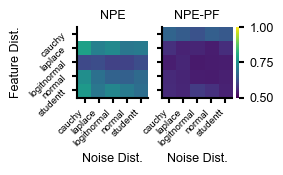

In [14]:
noise_scale = 1
feature_scale = 1
num_simulations = 1000
dim = 5
plot_heatmap(noise_scale, feature_scale, num_simulations, dim, show=True)